In [5]:
import pandas as pd

df = pd.read_csv("CAR DETAILS.csv")

df.columns = df.columns.str.strip()

df['car_age'] = 2026 - df['year']

In [6]:
df = df.drop('name', axis=1)

In [7]:
df = pd.get_dummies(df, drop_first=True)

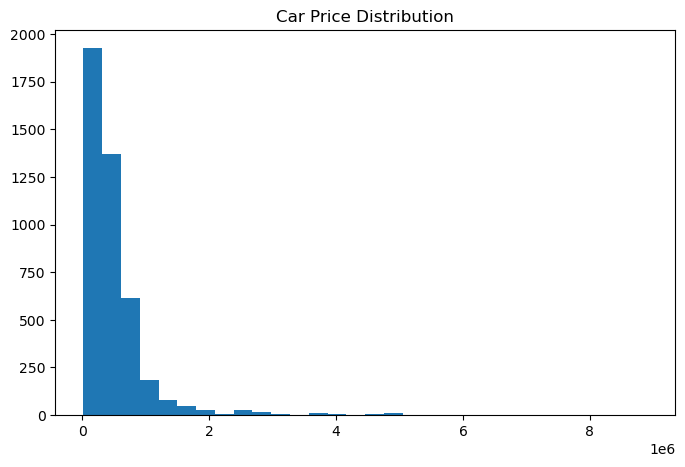

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df['selling_price'], bins=30)
plt.title("Car Price Distribution")
plt.show()

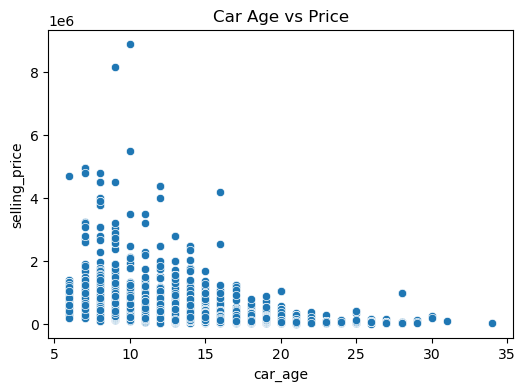

In [9]:
import seaborn as sns

plt.figure(figsize=(6,4))
sns.scatterplot(x=df['car_age'], y=df['selling_price'])
plt.title("Car Age vs Price")
plt.show()

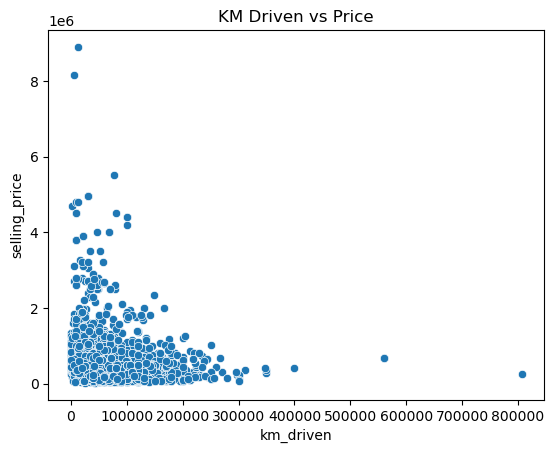

In [10]:
sns.scatterplot(x=df['km_driven'], y=df['selling_price'])
plt.title("KM Driven vs Price")
plt.show()

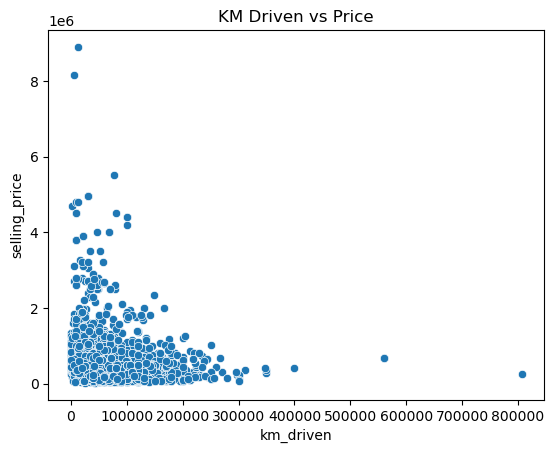

In [11]:
sns.scatterplot(x=df['km_driven'], y=df['selling_price'])
plt.title("KM Driven vs Price")
plt.show()

In [12]:
from sklearn.model_selection import train_test_split

X = df.drop('selling_price', axis=1)
y = df['selling_price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score

In [14]:
lr = LinearRegression()
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)
print("Linear Regression R2:", r2_score(y_test, pred_lr))

Linear Regression R2: 0.403130360143212


In [15]:
dt = DecisionTreeRegressor()
dt.fit(X_train, y_train)
pred_dt = dt.predict(X_test)
print("Decision Tree R2:", r2_score(y_test, pred_dt))

Decision Tree R2: 0.35242313068466047


In [16]:
rf = RandomForestRegressor()
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)
print("Random Forest R2:", r2_score(y_test, pred_rf))

Random Forest R2: 0.48881749925851503


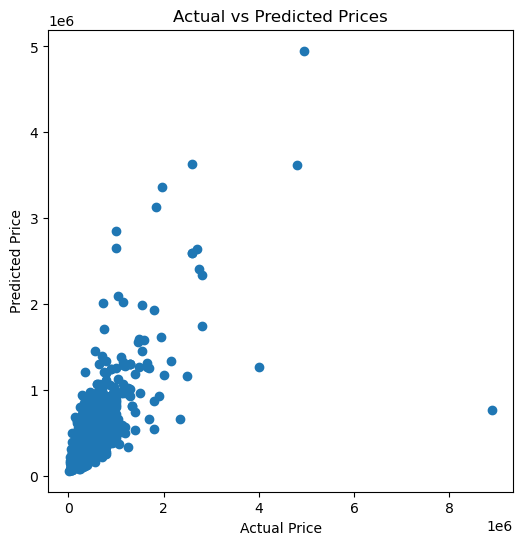

In [17]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, pred_rf)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")
plt.show()

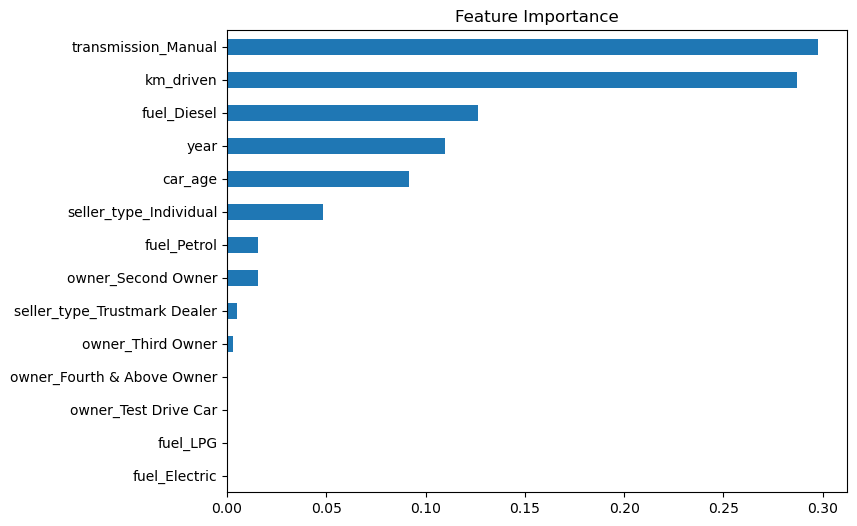

In [18]:
import pandas as pd

importance = pd.Series(rf.feature_importances_, index=X.columns)
importance.sort_values().plot(kind='barh', figsize=(8,6))
plt.title("Feature Importance")
plt.show()